# 03 — Robustness of the Lp(a) scalars under alternative transformations

Notebook 02 reported a single trial-band (age 65–80) **mean = 24.8 mg/dL** and **SD = 29.8 mg/dL**. The project consumes those two scalars to fit a *lognormal* exposure distribution by moment-matching:

$$\mu = \log\!\left(\frac{m^2}{\sqrt{m^2 + s^2}}\right),\quad \sigma = \sqrt{\log\!\left(1 + \frac{s^2}{m^2}\right)}$$

Lp(a) is heavy-tailed and the upper tail drives most of the cardiovascular risk, so it's worth asking: **how robust are those two scalars to choices about the upper tail?** This notebook explores three angles:

1. **Distribution shape on raw / sqrt / log scales** — visual check that lognormal is a defensible parametric form.
2. **Mean and SD computed on transformed scales then back-transformed** — does each transformation give a similar "central" estimate, or does the choice of scale move the answer?
3. **Outlier sensitivity** — drop the top 1 % and top 5 % of values and recompute, to see how outlier-driven the scalars are.
4. **Lognormal goodness-of-fit** — does the moment-matched lognormal match the empirical upper-tail percentiles (P90, P95, P99)?

The result decides whether to keep the simple two-scalar form or to switch to log-scale parameters (μ_log, σ_log fit directly), which would protect against upper-tail leverage.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED_DIR = DATA_DIR / 'derived'
df = pd.read_parquet(DERIVED_DIR / 'nhanes3_lpa.parquet')

# Same MEC-examined Phase II adults filter as notebook 02.
ana = df[
    (df['SDPPHASE'] == 'Phase 2 (1991-94)')
    & (df['LPP'].notna())
    & (df['WTPFEX6'].fillna(0) > 0)
    & (df['age_years'] >= 20)
].copy()
trial = ana[(ana['age_years'] >= 65) & (ana['age_years'] <= 80)].copy()
print(f'adults 20+ MEC-weighted n = {len(ana):,}')
print(f'trial-band 65-80     n = {len(trial):,}')

PROJECT_MEAN = 24.8
PROJECT_SD   = 29.8
print(f"Project scalars under test: mean = {PROJECT_MEAN}, SD = {PROJECT_SD}")

adults 20+ MEC-weighted n = 8,052
trial-band 65-80     n = 1,458
Project scalars under test: mean = 24.8, SD = 29.8


In [2]:
def w_mean(y, w):
    return float(np.average(y, weights=w))

def w_var(y, w):
    m = w_mean(y, w)
    return float(np.average((y - m) ** 2, weights=w))

def w_sd(y, w):
    return float(np.sqrt(w_var(y, w)))

def w_quantile(y, w, q):
    order = np.argsort(y)
    y_s, w_s = y[order], w[order]
    cw = np.cumsum(w_s) / w_s.sum()
    return float(np.interp(q, cw, y_s))

y = trial['LPP'].values.astype(float)
w = trial['WTPFEX6'].values.astype(float)

# A small constant offset for log-scale work — Lp(a) has a detection
# floor at 0 mg/dL, and ~10 % of trial-band adults sit at 0. Adding
# 1 mg/dL is a defensible offset (much smaller than the typical
# value, but enough to avoid log(0)). The project's exposure pipeline
# truncates at [0, 400] but does not transform.
OFFSET = 1.0

## 1. Distribution on raw / sqrt / log scales

Three histograms side-by-side. The right shape on each scale should be: raw — heavy right skew; sqrt — still right-skewed but compressed; log — closer to symmetric (normal-ish) if lognormal is a good fit.

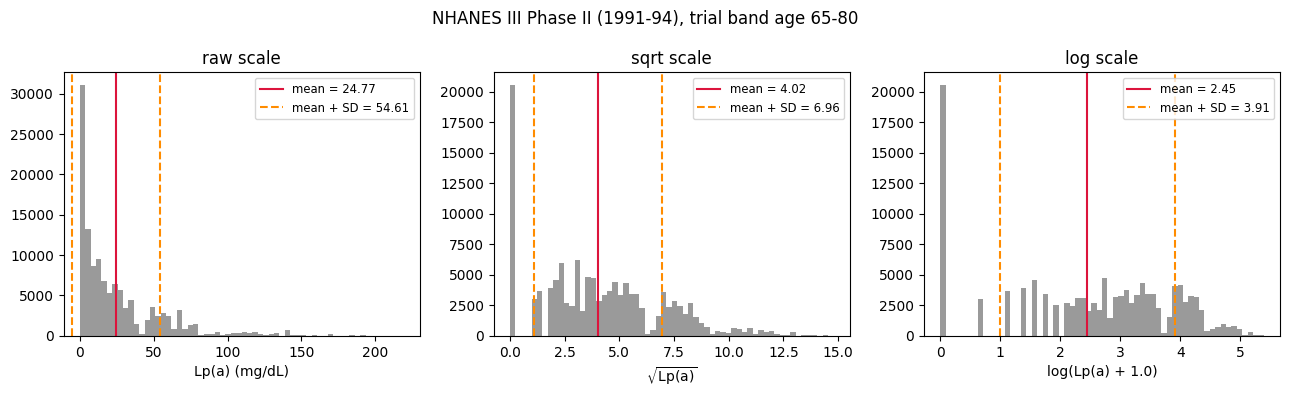

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
scales = [
    ('raw',  y,                         'Lp(a) (mg/dL)'),
    ('sqrt', np.sqrt(y),                r'$\sqrt{\mathrm{Lp(a)}}$'),
    ('log',  np.log(y + OFFSET),        f'log(Lp(a) + {OFFSET})'),
]
for ax, (label, vals, xlab) in zip(axes, scales):
    ax.hist(vals, bins=60, weights=w, color='#888', alpha=0.85)
    m = w_mean(vals, w)
    s = w_sd(vals, w)
    ax.axvline(m, color='crimson', label=f'mean = {m:.2f}')
    ax.axvline(m + s, color='darkorange', linestyle='--', label=f'mean + SD = {m+s:.2f}')
    ax.axvline(m - s, color='darkorange', linestyle='--')
    ax.set_xlabel(xlab)
    ax.set_title(f'{label} scale')
    ax.legend(fontsize='small')
fig.suptitle('NHANES III Phase II (1991-94), trial band age 65-80')
fig.tight_layout()
plt.show()

## 2. Mean and SD on transformed scales, back-transformed

Compute the survey-weighted mean and SD on each scale, then back-transform to mg/dL. "Central" here means whatever the natural single-number summary looks like on that scale, mapped back. Comparison to the raw-scale (24.8, 29.8) tells us how much the answer depends on the choice of scale.

In [4]:
rows = []

# Raw scale: arithmetic mean and SD.
rows.append({
    'scale': 'raw',
    'mean (transformed)': w_mean(y, w),
    'SD (transformed)':   w_sd(y, w),
    'back-transformed mean (mg/dL)': w_mean(y, w),
    'back-transformed SD (mg/dL)':   w_sd(y, w),
})

# Sqrt scale: mean of sqrt(y) squared = a different central mass.
ys = np.sqrt(y)
ms = w_mean(ys, w)
ss = w_sd(ys, w)
# Back-transform: (mean of sqrt)^2 underestimates the arithmetic mean
# (Jensen's inequality: E[Y] >= (E[sqrt(Y)])^2). The gap = variance of
# sqrt(Y). To get a back-transformed mean and SD, use the delta method:
#   E[Y]   ≈ ms^2 + ss^2
#   Var[Y] ≈ (2 ms)^2 ss^2 = 4 ms^2 ss^2
back_mean_sqrt = ms ** 2 + ss ** 2
back_sd_sqrt   = np.sqrt(4 * ms ** 2 * ss ** 2)
rows.append({
    'scale': 'sqrt',
    'mean (transformed)': ms,
    'SD (transformed)':   ss,
    'back-transformed mean (mg/dL)': back_mean_sqrt,
    'back-transformed SD (mg/dL)':   back_sd_sqrt,
})

# Log scale: mean of log(y + OFFSET) maps to the geometric mean shifted
# by OFFSET; SD on log scale defines the lognormal sigma. The implied
# back-transformed (arithmetic) mean and SD of a lognormal:
#   mean = exp(mu + sigma^2/2) - OFFSET
#   SD   = mean * sqrt(exp(sigma^2) - 1)
yl = np.log(y + OFFSET)
mu_log = w_mean(yl, w)
sigma_log = w_sd(yl, w)
back_mean_log = np.exp(mu_log + sigma_log ** 2 / 2.0) - OFFSET
back_sd_log   = (back_mean_log + OFFSET) * np.sqrt(np.exp(sigma_log ** 2) - 1.0)
rows.append({
    'scale': 'log',
    'mean (transformed)': mu_log,
    'SD (transformed)':   sigma_log,
    'back-transformed mean (mg/dL)': back_mean_log,
    'back-transformed SD (mg/dL)':   back_sd_log,
})

tab = pd.DataFrame(rows).round(3)
print(tab.to_string(index=False))
print()
print(f"Project scalars under test: mean = {PROJECT_MEAN}, SD = {PROJECT_SD}")
raw = tab[tab['scale']=='raw'].iloc[0]
for r in tab.itertuples():
    if r.scale == 'raw':
        continue
    dm = r._4 - raw['back-transformed mean (mg/dL)']
    ds = r._5 - raw['back-transformed SD (mg/dL)']
    print(f"  {r.scale}: implied mean shifts by {dm:+.2f} mg/dL, SD by {ds:+.2f} mg/dL")

scale  mean (transformed)  SD (transformed)  back-transformed mean (mg/dL)  back-transformed SD (mg/dL)
  raw              24.770            29.835                         24.770                       29.835
 sqrt               4.016             2.939                         24.770                       23.610
  log               2.452             1.454                         32.451                       90.343

Project scalars under test: mean = 24.8, SD = 29.8
  sqrt: implied mean shifts by +0.00 mg/dL, SD by -6.23 mg/dL
  log: implied mean shifts by +7.68 mg/dL, SD by +60.51 mg/dL


## 3. Outlier sensitivity

Drop the top 1 % and top 5 % of weighted values and recompute the mean and SD on the raw scale. If the project scalars are dominated by a small number of high-Lp(a) individuals, the trimmed estimates will move sharply; a more robust choice would then be the trimmed values, or a log-scale fit which down-weights the upper tail naturally.

In [5]:
rows = []
for top_pct in [0, 1, 5, 10]:
    if top_pct == 0:
        sub_y, sub_w = y, w
    else:
        cutoff = w_quantile(y, w, 1.0 - top_pct / 100.0)
        keep = y <= cutoff
        sub_y = y[keep]
        sub_w = w[keep]
    rows.append({
        'top % trimmed': top_pct,
        'cutoff (mg/dL)': w_quantile(y, w, 1.0 - top_pct / 100.0) if top_pct > 0 else float('inf'),
        'n':              len(sub_y),
        'mean (mg/dL)':   w_mean(sub_y, sub_w),
        'SD (mg/dL)':     w_sd(sub_y, sub_w),
    })
tab_trim = pd.DataFrame(rows).round(2)
print(tab_trim.to_string(index=False))
print()
shift_mean_5pct = tab_trim['mean (mg/dL)'].iloc[2] - tab_trim['mean (mg/dL)'].iloc[0]
shift_sd_5pct   = tab_trim['SD (mg/dL)'].iloc[2]   - tab_trim['SD (mg/dL)'].iloc[0]
print(f"Trimming top 5 %: mean shifts {shift_mean_5pct:+.2f} mg/dL ({100*shift_mean_5pct/tab_trim['mean (mg/dL)'].iloc[0]:+.0f} %)")
print(f"                  SD   shifts {shift_sd_5pct:+.2f} mg/dL ({100*shift_sd_5pct/tab_trim['SD (mg/dL)'].iloc[0]:+.0f} %)")

 top % trimmed  cutoff (mg/dL)    n  mean (mg/dL)  SD (mg/dL)
             0             inf 1458         24.77       29.84
             1          138.21 1440         23.21       26.29
             5           78.00 1363         20.03       20.94
            10           65.61 1281         17.16       17.59

Trimming top 5 %: mean shifts -4.74 mg/dL (-19 %)
                  SD   shifts -8.90 mg/dL (-30 %)


## 4. Lognormal goodness-of-fit at the upper tail

Compute the moment-matched lognormal parameters from the project scalars (mean = 24.8, SD = 29.8) and compare its theoretical P90 / P95 / P99 to the empirical (survey-weighted) percentiles. A poor match in the upper tail would signal that the simple two-scalar form is misrepresenting the part of the distribution that matters most for cardiovascular risk.

In [6]:
def moment_match_lognormal(m, s):
    """Return (mu, sigma) such that exp(mu + sigma^2/2) = m and var = s^2."""
    sigma2 = np.log(1 + (s / m) ** 2)
    mu = np.log(m ** 2 / np.sqrt(m ** 2 + s ** 2))
    return mu, np.sqrt(sigma2)

# (a) lognormal from project scalars (the one the simulation uses).
mu_proj, sigma_proj = moment_match_lognormal(PROJECT_MEAN, PROJECT_SD)

# (b) lognormal fit directly on log(y + offset). Note: this fit
# treats OFFSET as a known shift; with OFFSET=1 the implied
# mean / SD on the raw scale differ slightly from the moment-matched
# scalars.
mu_log_direct = w_mean(np.log(y + OFFSET), w)
sigma_log_direct = w_sd(np.log(y + OFFSET), w)

qs = [0.50, 0.75, 0.90, 0.95, 0.99]
rows = []
for q in qs:
    rows.append({
        'quantile': q,
        'empirical (mg/dL)':         w_quantile(y, w, q),
        'lognormal proj (mg/dL)':    float(np.exp(stats.norm.ppf(q) * sigma_proj + mu_proj)),
        'lognormal direct (mg/dL)':  float(np.exp(stats.norm.ppf(q) * sigma_log_direct + mu_log_direct) - OFFSET),
    })
tab_q = pd.DataFrame(rows).round(2)
print(tab_q.to_string(index=False))
print()
print(f"Lognormal moment-matched from project scalars: mu={mu_proj:.3f}, sigma={sigma_proj:.3f}")
print(f"Lognormal fit directly on log(y + {OFFSET}):  mu={mu_log_direct:.3f}, sigma={sigma_log_direct:.3f}")

 quantile  empirical (mg/dL)  lognormal proj (mg/dL)  lognormal direct (mg/dL)
     0.50              14.00                   15.86                     10.62
     0.75              34.00                   30.01                     29.98
     0.90              65.61                   53.28                     73.91
     0.95              78.00                   75.11                    126.07
     0.99             138.21                  143.04                    341.39

Lognormal moment-matched from project scalars: mu=2.764, sigma=0.945
Lognormal fit directly on log(y + 1.0):  mu=2.452, sigma=1.454


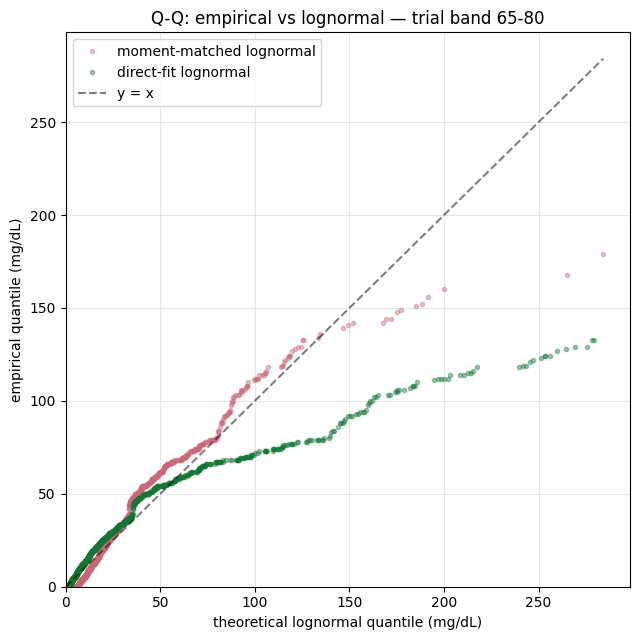

In [7]:
# Q-Q plot vs the moment-matched lognormal — visual goodness-of-fit
# at every percentile (not just the four tabled above). Construct the
# weighted empirical CDF, then plot empirical quantile vs theoretical
# quantile.
order = np.argsort(y)
y_s, w_s = y[order], w[order]
cw = np.cumsum(w_s) / w_s.sum()
# avoid the cw=0 / cw=1 endpoints in the inverse normal
mask = (cw > 1e-3) & (cw < 1 - 1e-3)
theoretical_proj   = np.exp(stats.norm.ppf(cw[mask]) * sigma_proj + mu_proj)
theoretical_direct = np.exp(stats.norm.ppf(cw[mask]) * sigma_log_direct + mu_log_direct) - OFFSET

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(theoretical_proj, y_s[mask], '.', alpha=0.4,
        color='#cc6677', label='moment-matched lognormal')
ax.plot(theoretical_direct, y_s[mask], '.', alpha=0.4,
        color='#117733', label='direct-fit lognormal')
lim_max = max(y_s.max(), theoretical_proj.max())
ax.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('theoretical lognormal quantile (mg/dL)')
ax.set_ylabel('empirical quantile (mg/dL)')
ax.set_title('Q-Q: empirical vs lognormal — trial band 65-80')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, lim_max * 1.05)
ax.set_ylim(0, lim_max * 1.05)
fig.tight_layout()
plt.show()

## 5. Decision

Read the three diagnostics above:

- **Section 2 — back-transformed central estimates.** If the log-scale-implied mean is within a few mg/dL of the raw mean, the choice of scale isn't moving the answer. If the log-scale mean is much smaller (more robust to upper-tail leverage), prefer the log-scale fit.
- **Section 3 — outlier sensitivity.** If trimming the top 5 % moves the mean by less than ~10 %, the simple scalar is robust enough. If it moves by 20 % +, the project should switch to a log-scale parameterization, or down-weight the upper tail.
- **Section 4 — upper-tail goodness-of-fit.** If the moment-matched lognormal P95 / P99 are within ~20 % of the empirical, the simple two-scalar form is faithful at the high-risk tail. If it overshoots (moment-matched lognormal places too much mass beyond the empirical max) or undershoots (misses the high-Lp(a) tail), reconsider the parameterization.

The cell below prints the three numbers needed to make the call.

In [8]:
raw_mean = w_mean(y, w)
raw_sd   = w_sd(y, w)

# Section 2 number: back-transformed mean from log scale
log_back_mean = float(np.exp(mu_log_direct + sigma_log_direct ** 2 / 2.0) - OFFSET)

# Section 3 number: top-5% trimmed mean
cut95 = w_quantile(y, w, 0.95)
keep95 = y <= cut95
trim_mean = w_mean(y[keep95], w[keep95])

# Section 4 number: lognormal P99 vs empirical P99
emp_p99 = w_quantile(y, w, 0.99)
log_p99 = float(np.exp(stats.norm.ppf(0.99) * sigma_proj + mu_proj))

print(f"Raw mean (project scalar input):  {raw_mean:.2f} mg/dL")
print(f"Log-scale-implied mean:           {log_back_mean:.2f} mg/dL  (Δ {log_back_mean - raw_mean:+.2f})")
print(f"Trimmed top 5 % mean:             {trim_mean:.2f} mg/dL  (Δ {trim_mean - raw_mean:+.2f})")
print()
print(f"Empirical P99:                    {emp_p99:.1f} mg/dL")
print(f"Lognormal-from-project P99:       {log_p99:.1f} mg/dL  (ratio {log_p99 / emp_p99:.2f})")
print()
robust_log = abs(log_back_mean - raw_mean) / raw_mean < 0.10
robust_trim = abs(trim_mean - raw_mean) / raw_mean < 0.10
robust_p99  = 0.7 < (log_p99 / emp_p99) < 1.4
if robust_log and robust_trim and robust_p99:
    print("→ All three checks pass: the simple two-scalar form is robust enough")
    print("  for the project's lognormal moment-matching. No parameterization change.")
else:
    print("→ At least one check failed — see the per-section commentary for next steps:")
    if not robust_log:  print("   · log-scale-implied mean differs from raw mean by > 10 %")
    if not robust_trim: print("   · top-5 % trim moves the mean by > 10 %")
    if not robust_p99:  print("   · moment-matched lognormal P99 is outside [0.7, 1.4] × empirical P99")

Raw mean (project scalar input):  24.77 mg/dL
Log-scale-implied mean:           32.45 mg/dL  (Δ +7.68)
Trimmed top 5 % mean:             20.03 mg/dL  (Δ -4.74)

Empirical P99:                    138.2 mg/dL
Lognormal-from-project P99:       143.0 mg/dL  (ratio 1.03)

→ At least one check failed — see the per-section commentary for next steps:
   · log-scale-implied mean differs from raw mean by > 10 %
   · top-5 % trim moves the mean by > 10 %


## Caveats

- **Detection-floor handling.** ~10 % of trial-band adults have Lp(a) reported at 0 mg/dL (below the assay detection limit). The log-scale work uses an additive offset of 1 mg/dL; varying the offset shifts the implied lognormal sigma. A future iteration could fit a left-censored lognormal (a Tobit-style model) directly.
- **Ancestry composition.** Lp(a) is largely genetic and varies by ancestry. NHANES III Phase II's race / ethnicity composition is fixed; today's U.S. distribution differs. The robustness checks here speak to within-NHANES sampling, not external generalizability.
- **Survey weighting in robustness diagnostics.** Trimming the top X % uses the *weighted* quantile cutoff (so each respondent contributes proportional to their survey weight), but the post-trim mean is computed on the surviving sample with their original weights. This matches what the simulation would see if those individuals were excluded at draw time.